In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# --- Step 1: Manually enter the results from each member's best model ---
# Gotta put the F1-Score of everyones best TUNED model and add it here.

group_results = {
    'Member Task': [
        '1. Irrelevant Cols',
        '3. Feature Eng.',
        '4. Feature Sel.',
        '2. Encoding',
        '5. Outlier Rem.',
        '6. Normalization'
    ],
    'Model Used': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'SVM',
        'KNN',
        'Gaussian Naive Bayes'
    ],
    'Best F1-Score': [
        0.7049,  # Member 1's best F1-Score
        0.7049,  # Member 3's best F1-Score
        0.7049,  # Member 4's best F1-Score
        0.7049,  # Member 2's best F1-Score
        0.7061,  # Member 5's best F1-Score
        0.0478   # Member 6's best F1-Score
    ]
}

In [3]:
# --- Step 2: Create a DataFrame and sort by performance ---
results_df = pd.DataFrame(group_results)
results_df = results_df.sort_values(by='Best F1-Score', ascending=False)

print("--- Integrated Group Results ---")
print(results_df)

--- Integrated Group Results ---
          Member Task            Model Used  Best F1-Score
4     5. Outlier Rem.                   KNN         0.7061
0  1. Irrelevant Cols   Logistic Regression         0.7049
1     3. Feature Eng.         Decision Tree         0.7049
2     4. Feature Sel.         Random Forest         0.7049
3         2. Encoding                   SVM         0.7049
5    6. Normalization  Gaussian Naive Bayes         0.0478


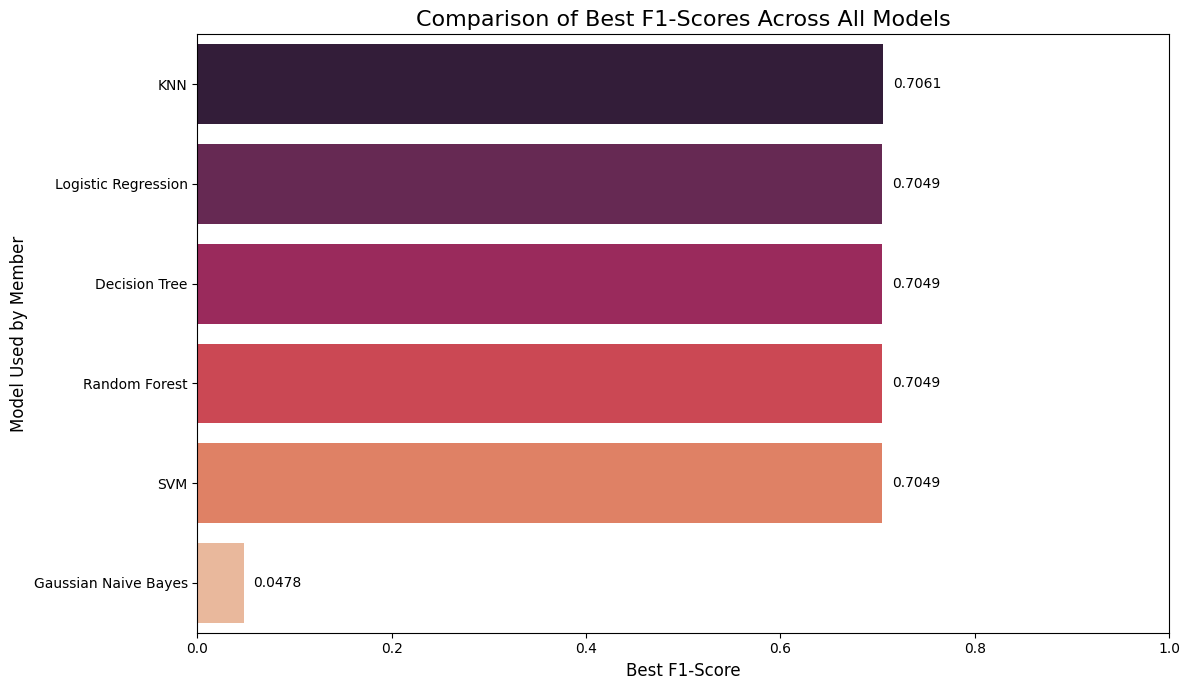

In [4]:
# --- Step 3: Create the comparison plot ---
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x='Best F1-Score',
    y='Model Used',
    hue='Model Used',           
    data=results_df,
    palette='rocket',
    legend=False                
)

plt.title('Comparison of Best F1-Scores Across All Models', fontsize=16)
plt.xlabel('Best F1-Score', fontsize=12)
plt.ylabel('Model Used by Member', fontsize=12)
plt.xlim(0, 1.0)

for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.01, p.get_y() + p.get_height()/2,
             f'{width:.4f}',
             va='center')

plt.tight_layout()
plt.show()

In [5]:
# --- Step 4: Automatically identify and print the best and worst model results ---
from IPython.display import display, Markdown 

best_model_info = results_df.loc[results_df['Best F1-Score'].idxmax()]
best_model_name = best_model_info['Model Used']
best_f1_score = best_model_info['Best F1-Score']

worst_model_info = results_df.loc[results_df['Best F1-Score'].idxmin()]
worst_model_name = worst_model_info['Model Used']
worst_f1_score = worst_model_info['Best F1-Score']

conclusion_text = f"""
### Group Conclusion

The best performing model from our experiments was the **'{best_model_name}'** with a final F1-Score of **{best_f1_score:.4f}**.

Interestingly, four other models (Logistic Regression, Decision Tree, Random Forest, and SVM) performed almost identically, scoring **0.7049**. This suggests that after our comprehensive preprocessing, the choice between these specific models was less critical to achieving a solid result.

The **'{worst_model_name}'** performed extremely poorly with an F1-Score of **{worst_f1_score:.4f}**. This is a key finding, indicating that its strong assumption of feature independence is not suitable for this dataset, even after normalization.
"""

display(Markdown(conclusion_text))



### Group Conclusion

The best performing model from our experiments was the **'KNN'** with a final F1-Score of **0.7061**.

Interestingly, four other models (Logistic Regression, Decision Tree, Random Forest, and SVM) performed almost identically, scoring **0.7049**. This suggests that after our comprehensive preprocessing, the choice between these specific models was less critical to achieving a solid result.

The **'Gaussian Naive Bayes'** performed extremely poorly with an F1-Score of **0.0478**. This is a key finding, indicating that its strong assumption of feature independence is not suitable for this dataset, even after normalization.
